In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

print(df.shape)

(284807, 31)


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Model Trained")

Model Trained


In [4]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test[:1000])

print("SHAP values generated")

d:\CreditCardFraudDetection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values generated


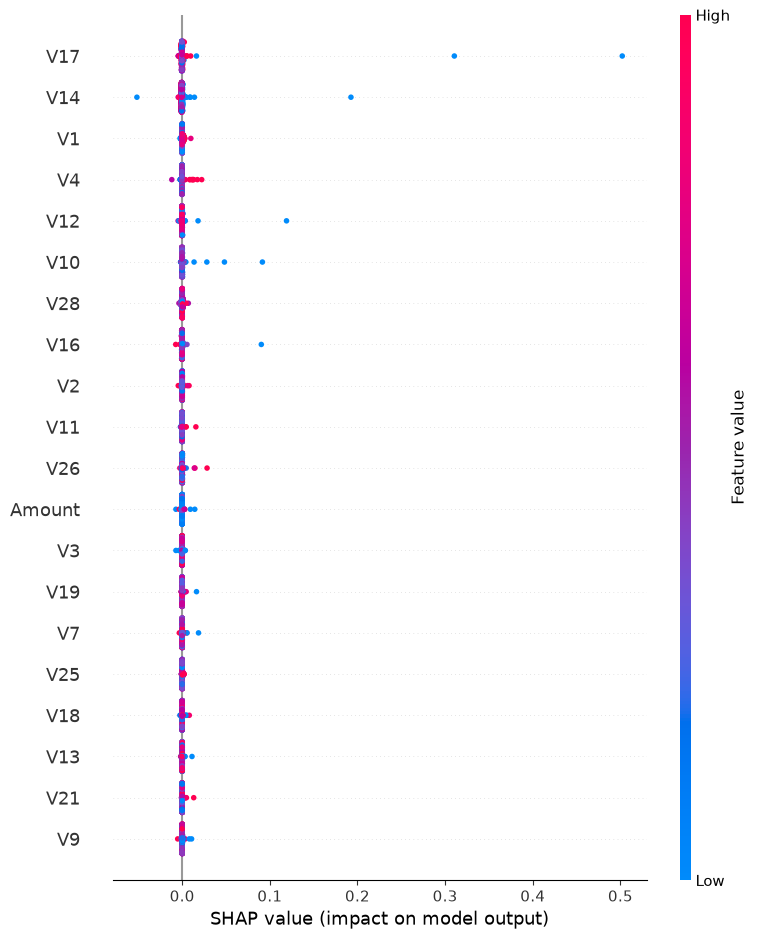

In [5]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test[:1000]
)

In [6]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
17     V17    0.170325
14     V14    0.136363
12     V12    0.133326
10     V10    0.074073
16     V16    0.071792
11     V11    0.045277
9       V9    0.031127
4       V4    0.030496
18     V18    0.028156
7       V7    0.024627
